---
title: "📐The Hidden Geometry of Software Coupling (Part 1)"
date: 2026-03-09 00:11:50 -0500
categories:
  - sdlc
  - architecture
  - coupling
  - metrics
author: steven
---

# 📐 The Hidden Geometry of Software Coupling
### Part 1 — The Metrics That Predict Architectural Failure
![📐 The Hidden Geometry of Software Coupling](https://raw.githubusercontent.com/git-steven/git-steven.github.io/master/assets/images/coupling-sm.png)

In [6]:

# ============================================================
# SETUP — Run this first!
# ============================================================

import base64
import json
import re
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as Color
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
from matplotlib.ticker import FuncFormatter
import nbformat

print("✅ matplotlib version:", mpl.__version__)
print("✅ Setup complete!")

# ============================================================
# 🎨 ARTICLE STYLE + SHARED CONFIGURATION
# ============================================================

PALETTE = {
    "paper_bg": "#EFE7D6",
    "plot_bg": "#E6DDCB",
    "grid": "#8E8474",
    "axis": "#2E4369",
    "zone_pain": "#B25E5E",
    "zone_useless": "#9086C4",
    "main_seq": "#4DAA57",
    "guide": "#8A8276",
    # "label_bg": "#FCF5E5",
    "label_bg": "#ABCDDB",
    "danger_text": "#8B0000",
    "distance_text": "#4F4A43",
    "stable_band": "#91B98A",
    "mostly_stable_band": "#B9C98B",
    "borderline_band": "#D9BF74",
    "volatile_band": "#C97C7C",
}

TEXT_STYLE = {
    "title": {
        "fontsize": 23,
        "fontstyle": "italic",
        "family": "DejaVu Serif",
        "color": PALETTE["axis"],
        "pad": 28,
    },
    "subtitle": {
        "fontsize": 18,
        "family": "DejaVu Sans Mono",
        "color": PALETTE["axis"],
    },
    "axis_label": {
        "fontsize": 16,
        "color": PALETTE["axis"],
    },
    "zone_label": {
        "fontsize": 13,
        "family": "DejaVu Serif",
        "fontweight": "semibold",
        "color": PALETTE["danger_text"],
    },
    "point_label": {
        "fontsize": 11,
        "color": PALETTE["axis"],
    },
    "distance_label": {
        "fontsize": 10,
        "color": PALETTE["distance_text"],
    },
    "curve_label": {
        "fontsize": 11,
        "family": "DejaVu Serif",
        "fontweight": "bold",
    },
}

AXIS_CONFIG = {
    "main_sequence": {
        "xlim": (0, 1),
        "ylim": (0, 1),
        "xticks": np.arange(0, 1.01, 0.1),
        "yticks": np.arange(0, 1.01, 0.1),
        "xlabel": "I (Instability) →",
        "ylabel": "A (Abstractness) →",
        "aspect": "equal",
        "grid_alpha": 0.20,
        "grid_linewidth": 1,
    },
    "instability_curves": {
        "xlim": (0, 20),
        "ylim": (0, 1.02),
        "xticks": [0, 5, 10, 15, 20],
        "yticks": [0, 0.25, 0.50, 0.75, 1.0],
        "xlabel": "Ce (Efferent Coupling)",
        "ylabel": "I = Instability",
        "aspect": None,
        "grid_alpha": 0.14,
        "grid_linewidth": 1,
    },
}

MODULES = [
    {"name": "Database Schema", "I": 0.1, "A": 0.1, "color": "#E53935"},
    {"name": "Unused Interfaces", "I": 0.9, "A": 0.9, "color": "#1E40FF"},
    {"name": "Core Domain Interfaces", "I": 0.2, "A": 0.8, "color": "#0B8A0B"},
    {"name": "Domain Model", "I": 0.40, "A": 0.5, "color": "#1E8E1E"},
    {"name": "Service Layer", "I": 0.70, "A": 0.4, "color": "#169C16"},
    {"name": "Perfect Balance", "I": 0.50, "A": 0.50, "color": "#006400"},
    {"name": "API Gateway", "I": 0.90, "A": 0.30, "color": "#F4A000"},
    {"name": "Shared Utilities", "I": 0.3, "A": 0.4, "color": "#8A6D3B"},
    {"name": "Integration Adapter", "I": 0.9, "A": 0.1, "color": "#8C564B"},
]
for m in MODULES:
    m["D"] = abs(m["A"] + m["I"] - 1)

LABEL_OFFSETS = {
  "Database Schema":        (0.04, 0.0, "left", "center"),
  "Unused Interfaces":      (-0.03, 0.0, "right",  "center"),
  "Core Domain Interfaces": (0.03,  0.0, "left",  "center"),
  "Domain Model":           (-0.0275,0, "right", "center"),
  "Service Layer":          (0.03, 0.0, "left",  "center"),
  "Perfect Balance":        (0.04,  0.0, "left",  "center"),
  "API Gateway":            (-0.03,  0.0, "right",  "center"),
  "Shared Utilities":       (-0.03, 0.0, "right", "center"),
  "Integration Adapter":    (-0.03, 0.0, "right",  "center"),
}

DISTANCE_LABEL_OFFSETS = {
  "API Gateway": (0,0), #(0.05, 0.08),
  "Database Schema": (-0.125,-0.125), #(-0.2, -0.16),
  "Domain Model": (0,0), #(-0.2, -0.16),
  "Service Layer": (0,0), #(0.03, 0.06),
  "Shared Utilities": (-0.05, -0.05),
  "Integration Adapter": (0,0), #(0.0, 0.0),
  "Unused Interfaces": (0.15, 0.15),

}

ZONE_LABEL_POSITIONS = {
  "pain": (0.01, 0.01),
  "useless": (0.99, 0.99),
}

CURVE_CA_VALUES = [0, 1, 2, 3, 5, 10, 15, 20]
CURVE_COLORS = ["#9D1A1A", "#FF2626", "#FF6A00", "#E58A00", "#5EA400", "#0EA5A8", "#2563EB", "#7C3AED"]


# Additional configuration for instability curves. By configuring these values here rather than inside
# the plotting function we ensure the entire visualization can be tuned without editing code logic.
CURVE_NUM_POINTS = 401  # number of Ce samples to compute smooth curves
CURVE_LABEL_ALPHA = 0.60  # opacity for curve label backgrounds
CURVE_LABEL_OFFSET = -0.05  # vertical offset for curve labels relative to diagonal position
BAND_LABEL_X_OFFSET = 0.45  # horizontal offset for band labels relative to max Ce
BANDS = [
    (0.00, 0.25, PALETTE["stable_band"], "Stable", "STABLE"),
    (0.25, 0.50, PALETTE["mostly_stable_band"], "Mostly Stable", "MOSTLY STABLE"),
    (0.50, 0.75, PALETTE["borderline_band"], "Borderline", "BORDERLINE"),
    (0.75, 1.00, PALETTE["volatile_band"], "Volatile", "VOLATILE"),
]

FIGSIZE_MAIN = (10.8, 8.5)
FIGSIZE_DETAIL = (12.2, 9.0)
FIGSIZE_CURVES = (13.0, 8.8)

mpl.rcParams.update({
    "figure.facecolor": PALETTE["paper_bg"],
    "axes.facecolor": PALETTE["plot_bg"],
    "axes.edgecolor": PALETTE["axis"],
    "axes.labelcolor": PALETTE["axis"],
    "axes.titlecolor": PALETTE["axis"],
    "axes.titleweight": "semibold",
    "xtick.color": PALETTE["axis"],
    "ytick.color": PALETTE["axis"],
    "text.color": PALETTE["axis"],
    "font.size": 12,
    "font.family": "DejaVu Sans",
})

def tick_fmt(x, pos):
  return str(int(round(x))) if abs(x - round(x)) < 1e-9 else f"{x:.1f}"

TICK_FORMATTER = FuncFormatter(tick_fmt)

def project_to_main_sequence(i_value: float, a_value: float):
    proj_i = (i_value - a_value + 1) / 2
    proj_i = max(0.0, min(1.0, proj_i))
    proj_a = 1.0 - proj_i
    return proj_i, proj_a

def style_axes(ax, *, title, subtitle=None, axis_config, x_label_style=None, y_label_style=None, title_style=None, subtitle_style=None):
    cfg = axis_config
    x_label_style = x_label_style or TEXT_STYLE["axis_label"]
    y_label_style = y_label_style or TEXT_STYLE["axis_label"]
    title_style = title_style or TEXT_STYLE["title"]
    subtitle_style = subtitle_style or TEXT_STYLE["subtitle"]

    ax.set_xlim(*cfg["xlim"])
    ax.set_ylim(*cfg["ylim"])
    if cfg.get("aspect"):
        ax.set_aspect(cfg["aspect"], adjustable="box")
    ax.set_xlabel(cfg["xlabel"], labelpad=12, **x_label_style)
    ax.set_ylabel(cfg["ylabel"], labelpad=18, **y_label_style)
    ax.set_xticks(cfg["xticks"])
    ax.set_yticks(cfg["yticks"])
    ax.xaxis.set_major_formatter(TICK_FORMATTER)
    ax.yaxis.set_major_formatter(TICK_FORMATTER)
    ax.grid(True, color=PALETTE["grid"], alpha=cfg.get("grid_alpha", 0.2), linewidth=cfg.get("grid_linewidth", 1))
    ax.tick_params(length=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(PALETTE["axis"])
    ax.spines["bottom"].set_color(PALETTE["axis"])
    ax.set_title(title, **title_style)
    if subtitle:
        ax.text(
            0.5, 1.015, subtitle,
            transform=ax.transAxes,
            ha="center", va="bottom",
            **subtitle_style,
            zorder=10,
            bbox=dict(facecolor=PALETTE["paper_bg"], edgecolor="none", alpha=0.85, pad=0.2),
        )

def draw_zones(ax):
    """Draw the shaded zones and their labels on the given axes.

    The zone polygons are static, but the label positions and alignment are
    configured via ZONE_LABEL_POSITIONS. Labels are aligned left or right
    depending on the zone to avoid clashing with other elements in the plot.
    """
    pain = Polygon([(0, 0), (0, 0.5), (0.5, 0)], closed=True,
                   facecolor=PALETTE["zone_pain"], edgecolor="none", alpha=0.22, zorder=1)
    useless = Polygon([(1, 1), (1, 0.5), (0.5, 1)], closed=True,
                      facecolor=PALETTE["zone_useless"], edgecolor="none", alpha=0.24, zorder=1)
    ax.add_patch(pain)
    ax.add_patch(useless)

    # Draw zone labels with explicit alignment: the pain label anchors on the left
    # and the useless label anchors on the right.
    ax.text(*ZONE_LABEL_POSITIONS["pain"], "ZONE OF PAIN\n(Stable + Concrete)",
            ha="left", va="bottom", zorder=3, **TEXT_STYLE["zone_label"])

    ax.text(*ZONE_LABEL_POSITIONS["useless"], "ZONE OF USELESSNESS\n(Unstable + Abstract)",
            ha="right", va="top", zorder=3, **TEXT_STYLE["zone_label"])
def draw_main_sequence(ax, label="Main Sequence"):
    ax.plot([0, 1], [1, 0], color=PALETTE["main_seq"], linewidth=4, zorder=2, label=label)

def build_base_legend(include_distance_sample=False):
    handles = [
        Line2D([0], [0], color=PALETTE["zone_pain"], linewidth=8, alpha=0.22, label="Zone of Pain"),
        Line2D([0], [0], color=PALETTE["zone_useless"], linewidth=8, alpha=0.24, label="Zone of Uselessness"),
        Line2D([0], [0], color=PALETTE["main_seq"], linewidth=4, label="Main Sequence"),
    ]
    if include_distance_sample:
        handles.append(
            Line2D([0], [0], label="D = Distance from Main Sequence",
              marker="o", markersize=10, color=PALETTE["main_seq"],
              linestyle="--",
              linewidth=1.2,
            )
        )
    return handles

def render_main_sequence_conceptual():
    fig, ax = plt.subplots(figsize=FIGSIZE_MAIN)
    draw_zones(ax)
    draw_main_sequence(ax)

    ax.plot([0.50, 0.60], [0.50, 0.60], color=PALETTE["main_seq"],
            linestyle=(0, (2, 3)), linewidth=1.5, alpha=0.85, zorder=2)
    ax.scatter([0.60], [0.60], s=160, color=PALETTE["main_seq"], zorder=4)
    ax.text(
        0.625, 0.625, "D = Distance from Main Sequence",
        ha="center", va="center",
        fontsize=12, family="DejaVu Sans Mono",
        color=PALETTE["axis"], zorder=4,
        rotation=-45, rotation_mode='anchor', transform_rotates_text=True

    )

    style_axes(ax, title="Main Sequence", subtitle="A + I = 1", axis_config=AXIS_CONFIG["main_sequence"])
    ax.legend(
        handles=build_base_legend(include_distance_sample=True),
        frameon=False, loc="upper left", bbox_to_anchor=(1.08, 1.01),
        labelcolor=PALETTE["axis"], fontsize=12, borderaxespad=0.
    )
    fig.tight_layout(rect=(0, 0, 0.90, 0.98), pad=1.2)
    plt.show()

def render_distance_from_main_sequence():
    fig, ax = plt.subplots(figsize=FIGSIZE_DETAIL)
    draw_zones(ax)
    draw_main_sequence(ax)

    for m in MODULES:
        proj_i, proj_a = project_to_main_sequence(m["I"], m["A"])
        ax.plot(
            [m["I"], proj_i], [m["A"], proj_a],
            color=PALETTE["guide"], linewidth=1.2,
            linestyle=(0, (3, 3)), alpha=0.50, zorder=2
        )
        ax.scatter([proj_i], [proj_a], s=28, color=PALETTE["guide"], alpha=0.28, zorder=3)

    for m in MODULES:
        mod_nm:str = m["name"]
        ax.scatter([m["I"]], [m["A"]], s=320, color=m["color"],
                   edgecolor="white", linewidth=2.5, zorder=4)
        dx, dy, ha, va = LABEL_OFFSETS[mod_nm]
        ax.text(
            m["I"] + dx, m["A"] + dy, mod_nm,
            ha=ha, va=va, zorder=5, clip_on=True, **TEXT_STYLE["point_label"]
        )

    for m in MODULES:
        mod_nm:str = m["name"]
        if mod_nm not in DISTANCE_LABEL_OFFSETS or m["D"] <= 0.0001:
            continue
        ia:tuple[float, float] = project_to_main_sequence(m["I"], m["A"])
        mid_i:float = (m["I"] + ia[0]) / 2.0
        mid_a:float = (m["A"] + ia[1]) / 2.0

        # Calculate X & Y for distance label
        ddxy:tuple[float] = DISTANCE_LABEL_OFFSETS.get(mod_nm, (0.0, 0.0))
        x:float=mid_i + ddxy[0]
        y:float=mid_a + ddxy[1]

        # Get color and set alpha:
        rgba:tuple[float, float, float, float] = Color.to_rgba(PALETTE["label_bg"], alpha=0.35)

        ax.text(
            x, y, f"D={m['D']:.2f}",
            ha="center", va="center", zorder=6, **TEXT_STYLE["distance_label"],
            bbox=dict(
              aa=True, boxstyle="round,pad=0.18,rounding_size=0.1",
              color=rgba
            ),
            rotation=-45,
        )

    style_axes(ax, title="Distance from Main Sequence", subtitle="A + I = 1", axis_config=AXIS_CONFIG["main_sequence"])
    ax.legend(
        handles=build_base_legend(include_distance_sample=False),
        frameon=False, loc="upper left", bbox_to_anchor=(1.08, 1.01),
        labelcolor=PALETTE["axis"], fontsize=12, borderaxespad=0.
    )
    fig.tight_layout(rect=[0, 0, 0.90, 0.98], pad=1.2)
    plt.show()


def render_instability_curves():
    """
    Render the Instability Curves chart.

    This plot shows how the instability metric I = Ce / (Ce + Ca) varies as the number of efferent
    couplings (Ce) grows for different fixed values of afferent couplings (Ca). Each curve corresponds
    to a different Ca value from CURVE_CA_VALUES, and its colour is drawn from CURVE_COLORS. The curve
    labels are positioned along a diagonal from the top‑left to the bottom‑right of the chart with a
    configurable vertical offset (CURVE_LABEL_OFFSET) to ensure that they do not sit directly on the lines.
    All configurable parameters such as the number of points sampled, colours, band definitions and label
    opacities live in the configuration section at the top of this notebook.
    """
    fig, ax = plt.subplots(figsize=FIGSIZE_CURVES)

    # Draw stability bands using the global BANDS configuration. Each band is a shaded region across
    # the entire x‑axis with a semi‑transparent fill colour to indicate how stable a module is expected
    # to be at different instability values.
    for y0, y1, color, _, _ in BANDS:
        ax.axhspan(y0, y1, color=color, alpha=0.10, zorder=0)

    # Draw horizontal separators between bands for visual clarity.
    for _, y1, _, _, _ in BANDS[:-1]:
        ax.axhline(y1, color=PALETTE["grid"], linewidth=1.5, linestyle=(0, (6, 4)), alpha=0.45, zorder=1)

    # Define domain of efferent couplings (Ce) based on the axis configuration.
    ce_max = AXIS_CONFIG["instability_curves"]["xlim"][1]
    ce = np.linspace(0, ce_max, CURVE_NUM_POINTS)
    legend_handles = []
    ca_count = len(CURVE_CA_VALUES)

    # Generate and plot the instability curves for each Ca value.
    for idx, (ca, color) in enumerate(zip(CURVE_CA_VALUES, CURVE_COLORS)):
        # Compute instability values: avoid division by zero when Ca is zero.
        if ca == 0:
            i_vals = np.where(ce > 0, 1.0, np.nan)
        else:
            i_vals = ce / (ce + ca)
        ax.plot(ce, i_vals, color=color, linewidth=2.4, zorder=3)

        # Determine the label position along a diagonal from (0,1) to (ce_max,0).
        t = idx / (ca_count - 1) if ca_count > 1 else 0.0
        x_label = ce_max * t
        y_label = (1.0 - t) + CURVE_LABEL_OFFSET

        # Place the curve label with a translucent background.
        ax.text(
            x_label,
            y_label,
            f"Ca={ca}",
            color=color,
            ha="center",
            va="center",
            **TEXT_STYLE["curve_label"],
            bbox=dict(
                boxstyle="round,pad=0.25",
                fc=PALETTE["label_bg"],
                ec="none",
                alpha=CURVE_LABEL_ALPHA
            )
        )
        legend_handles.append(Line2D([0], [0], color=color, linewidth=6, label=f"Ca = {ca}"))

    # Place the descriptive band labels down the right-hand side of the chart.
    x_text = ce_max + BAND_LABEL_X_OFFSET
    for y0, y1, _, _, long_label in BANDS:
        y_mid = (y0 + y1) / 2
        ax.text(
            x_text, y_mid, long_label,
            color=PALETTE["axis"],
            rotation=90,
            va="center",
            ha="left",
            fontsize=10,
            fontweight="semibold",
        )

    # Apply consistent axis styling.
    style_axes(ax, title="Coupling Metrics\nInstability Curves", axis_config=AXIS_CONFIG["instability_curves"])

    # Build and render the legend. Use only Ca values; do not include band entries.
    ax.legend(
        handles=legend_handles,
        title="Ca Values",
        loc="center left",
        bbox_to_anchor=(-0.23, 0.45),
        frameon=True,
        facecolor=PALETTE["label_bg"],
        edgecolor="none",
        title_fontsize=12,
        fontsize=10
    )

    # Caption beneath the plot explaining the instability formula.
    fig.text(
        0.50, 0.03,
        r"Figure 2: How Instability (I) varies with coupling    $I = \dfrac{C_e}{C_e + C_a}$",
        ha="center", va="center",
        fontsize=14, family="DejaVu Serif", color=PALETTE["axis"],
        bbox=dict(
            boxstyle="round,pad=0.45",
            fc="#C7D6EF", ec="#8AA5D1",
            alpha=0.95
        )
    )

    fig.tight_layout(rect=[0.05, 0.07, 0.92, 0.98])
    plt.show()

def render_md(filename: str = "notebook.md", notebook_path: str | None = None):
    """
    Export the notebook to markdown including markdown cells and rendered outputs,
    but without code-cell inputs.
    """
    try:
        from nbconvert import MarkdownExporter
    except ImportError as e:
        raise RuntimeError("nbconvert is required for render_md()") from e

    if notebook_path is None:
        candidates = sorted(Path.cwd().glob("*.ipynb"), key=lambda p: p.stat().st_mtime, reverse=True)
        if not candidates:
            raise FileNotFoundError("No .ipynb files found in current directory. Pass notebook_path explicitly.")
        notebook_path = str(candidates[0])

    notebook_path = Path(notebook_path)
    nb_node = nbformat.read(notebook_path, as_version=4)

    exporter = MarkdownExporter()
    exporter.exclude_input = True
    exporter.exclude_input_prompt = True
    exporter.exclude_output_prompt = True

    body, resources = exporter.from_notebook_node(nb_node)

    output_path = Path(filename)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    body = re.sub(r"\n{3,}", "\n\n", body)
    output_path.write_text(body, encoding="utf-8")

    output_files_dir = output_path.parent
    for name, data in resources.get("outputs", {}).items():
        target = output_files_dir / name
        target.parent.mkdir(parents=True, exist_ok=True)
        if isinstance(data, str):
            try:
                target.write_bytes(base64.b64decode(data))
            except Exception:
                target.write_text(data, encoding="utf-8")
        else:
            target.write_bytes(data)

    print(f"✅ Markdown exported to {output_path}")
    if resources.get("outputs"):
        print(f"✅ Exported {len(resources['outputs'])} output asset(s)")
    return output_path

print("🎨 Configuration loaded")


✅ matplotlib version: 3.10.8
✅ Setup complete!
🎨 Configuration loaded


## 📃Introduction

Software engineers love to talk about architecture in qualitative terms.

- *“This module feels tightly coupled”*
- *“That dependency seems risky”*
- *“This design is flexible”*

But beneath those instincts lies something far more concrete
* 🏗 The structure of software systems **_can be measured_**
* 🏛️ Architectural problems can be predicted and addressed **long before production failures reveal them**.
* 🕰 The formulas behind these metrics have been around since the 1990s
* 🤖 They require no machine learning
* 🧮 Just counting (...and occasionally a little division)


## 🗿The Architecture that was “pretty good”… until it opened a hellmouth 👹

_For the first six months, even a year, everything felt fast.  Our Ruby-on-Rails application was humming along and new features were added daily_
* ⏲  Features shipped quickly
* 🐞 Bug fixes took hours, not days
* 🧑‍💻 Engineers felt productive

_Then, something strange started happening; it began to shift:_
* ⏳ A simple change began taking longer
* 🔗 A feature that should have been isolated to one component suddenly required edits across seemingly-unrelated code; models, controllers, helpers, serializers, background jobs, etc.

_Then the real symptoms appeared:_
* 🧟 Engineers no longer feel productive
* 👥 New engineers joined the team and couldn't make heads or tails of the system.
* ⛓️ Bug fixes triggered unrelated failures.
* 🐞🐞🐞 A “small refactor” broke three features nobody expected to be connected.
* ☣ Every change started to feel dangerous.

## Architecture and Coupling
Eventually they hire an architect, who spends some time with the codebase(s) and running various tools

> Your problem isn’t Rails. Your problem is **coupling**.

All the software engineers had heard of this, of course, but thought of it as a _qualitative_ measurement.  It may have come up a few times since, but had never been _exactly quantified_.  Now here it is in the real world.

The application had quietly evolved into something **infamous**:

### A Tightly Coupled Monolith
>  It's a simple complex system.  Because it's simple, it's prone to cascades, and because it's complex, you can't predict what's going to fail. Or how. -- _"The Expanse"_

**Note:** _Coupling can still be a huge problem even if the software in question is **not** a monolith_


**When software is tightly coupled**
* A change almost anywhere could trigger side effects somewhere else
* Features that should have touched one module required edits across five
* Bug fixes became archaeology

### And the surprising part?
* These structural problems weren't mysterious
* They were **measurable** and **preventable**

## Coupling Metrics
![Coupling Metrics](https://raw.githubusercontent.com/git-steven/git-steven.github.io/master/assets/images/coupling-metrics-sm.png)

### 📐 The Two Numbers That Explain Most Architecture

Nearly every structural coupling metric derives from two simple counts.

```text
        Who depends on me?
                ↑
               Ca
                │
                ● GIVEN MODULE/PACKAGE
                │
               Ce
                ↓
        Upon whom do I depend?
```

### Afferent Coupling (Ca)

```text
Ca = number of external modules that depend on this one
```

Afferent coupling measures **responsibility**.

If many modules depend on you, your stability matters.

Break this module, and others break too.

Modules with high Ca become **structural anchors**.

### Efferent Coupling (Ce)

```text
Ce = number of external modules this module depends on
```

Efferent coupling measures **vulnerability**.

The more dependencies you have, the more ways your code can break.

Every dependency introduces:

- version risk
- semantic assumptions
- upgrade friction

Dependencies are powerful.

But they are never free.

### 🧮 A Simple Analogy

These metrics behave like a financial balance sheet.

| Metric                     | Analogy                        |
|----------------------------|--------------------------------|
| `Ca` *(Afferent Coupling)* | Creditors (who depends on you) |
| `Ce` *(Efferent Coupling)* | Debts (who you depend on)      |

* Modules with many creditors must be **_stable_**.
* Modules with many debts are inherently **_fragile_**.
---

## 🧭 The Instability Index (I)
![🛰 Instability (fig. 1)](https://raw.githubusercontent.com/git-steven/git-steven.github.io/master/assets/images/metrics-instability-fig1-overview.png)

From Ca and Ce we derive a powerful ratio.

```
𝐼 = 𝐶ₑ / (𝐶ₑ + 𝐶ₐ)
```

Instability ranges from **0 to 1**.

| I Range | Stability | Meaning | Change Strategy |
|---|---|---|---|
| 0.0 ≤ I < 0.25 | Stable | Many dependents, few dependencies | Change with care |
| 0.25 ≤ I < 0.50 | Balanced | Healthy structural position | Normal dev pace |
| 0.50 ≤ I < 0.75 | Borderline | Dependency heavy | Monitor closely |
| 0.75 ≤ I ≤ 1.0 | Unstable | Few dependents, many dependencies | Refactor freely |

The graph below shows how instability changes as **Ce** grows for different fixed values of **Ca**.

Low **Ca** produces curves that rise very quickly toward volatility.
Higher **Ca** dampens that rise, making the same increase in **Ce** less destabilizing.

This leads to one of the most important architectural principles.

### Stable Dependencies Principle

Dependencies should flow **toward stability**.

```text
unstable modules  →  stable modules
```

When stable modules depend on unstable ones, architectural fragility appears quickly.


## Instability Curves

The chart above shows how **Instability** changes as **Ce** grows for several fixed values of **Ca**.

A few patterns jump out immediately:

- When **Ca is low**, instability rises very quickly.
  Modules with few dependents become volatile with even a modest increase in outgoing dependencies.
- When **Ca is higher**, the curve climbs more slowly.
  A module with many dependents can absorb some additional dependencies before drifting into the more unstable bands.
- The `Ca = 0` line is the extreme case.
  A module with no dependents is structurally free to become maximally unstable.

This is why **Ce** is not the whole story by itself.
The same number of outgoing dependencies means something different depending on how much responsibility the module already carries.

Said another way: instability is not merely about *how much you depend on* — it is about that dependency load **relative to who depends on you**.

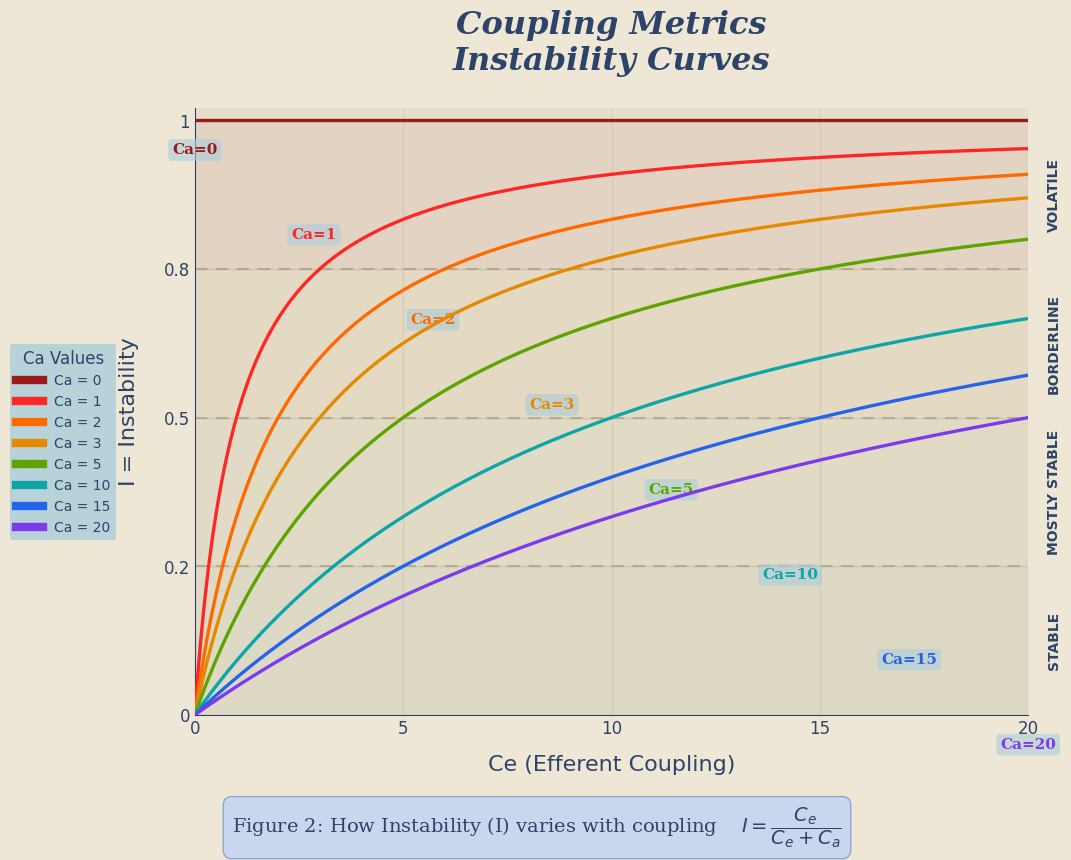

In [7]:
render_instability_curves()

### Description (Instability Curves)
The instability curves plot the ratio **I = C_e / (C_e + C_a)** as the number of efferent couplings (C_e) grows for a series of fixed afferent coupling counts (C_a).  Each curve shows how quickly a module will move from stable toward volatile as it accumulates outgoing dependencies.  When C_a is small, even a handful of efferent couplings causes I to rise sharply, meaning that leaf modules become unstable very quickly.  When C_a is large, the curves climb more gradually — a stable core module with many incoming dependents can tolerate more outgoing dependencies before becoming volatile.  In other words, high‑responsibility modules (large C_a) have more structural inertia against instability, while low‑responsibility modules rapidly drift into the volatile region as they add dependencies.  The metric I was defined by Robert Martin as the ratio of efferent coupling to total coupling and measures a package’s resilience to change: I = 0 indicates complete stability and I = 1 indicates complete instability.


## 🧬 Abstractness (A)

This metric differentiates types as **concrete** or **abstract** (`interface`/`protocol`/`port`).


```text
A = Na / Nc
```

### Where

* ``Na`` = number of abstract types
* ``Nc`` =`total number of types


### Interpretation
* ``A = 1`` → completely abstract
* ``A = 0`` → completely concrete

### Conclusion
* Abstraction provides flexibility
* Concrete code provides behavior
* Good architecture balances both
---

## 🧪 Main Sequence

When plotting **Abstractness (A)** against **Instability (I)**, something interesting appears.

Healthy modules tend to cluster along a line defined by:

```text
A + I = 1
```

This line is called the **Main Sequence**.

The conceptual graph below shows the terrain first:

- the **main-sequence line** itself
- the **Zone of Pain** in the lower-left
- the **Zone of Uselessness** in the upper-right
- a small illustrative distance marker showing how we measure deviation from the line

The key idea is simple: modules do not have to sit exactly on the main sequence, but the farther they drift from it, the more likely they are to be structurally imbalanced.

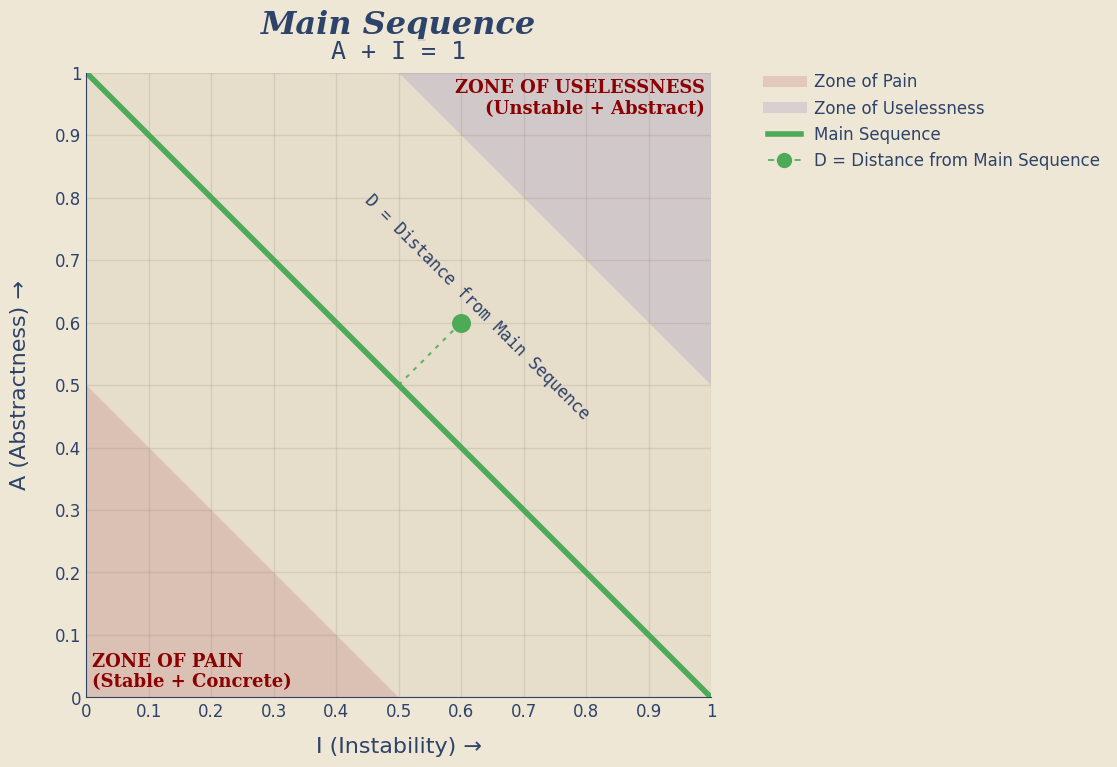

In [8]:
# ============================================================
# 📊 MAIN SEQUENCE — CONCEPTUAL VIEW
# ============================================================
render_main_sequence_conceptual()


## 🪨 Architectural Danger Zones

### Zone of Pain

```text
low A
low I
```

Meaning:

```text
concrete AND stable
```

These modules are depended on by many other modules but contain little abstraction.

Examples often include:

- database schemas
- configuration systems
- foundational libraries

Changing them causes cascading impact.

Hence the name.

### Zone of Uselessness

```text
high A
high I
```

Meaning:

```text
abstract AND unstable
```

These modules contain abstractions nobody uses.

Example:

```text
12 interfaces
1 implementation
0 dependents
```

Beautiful architecture.

No real purpose.

## 🧪 Distance From the Main Sequence

Once we place real modules on the same chart, the picture gets richer.

The detailed graph below shows:

- the **main sequence**
- the two architectural danger zones
- example modules in and out of those zones
- a dotted guide line from each module to its nearest point on the main sequence
- the **distance value** (`D`) for the more interesting examples

That lets us see not just *where* a module sits, but *how far off-balance* it is.

Some modules live outside the danger zones and are still worth watching. A service layer, API gateway, or shared utility package may not be pathological, but a non-zero distance still suggests the design is drifting away from the ideal balance.


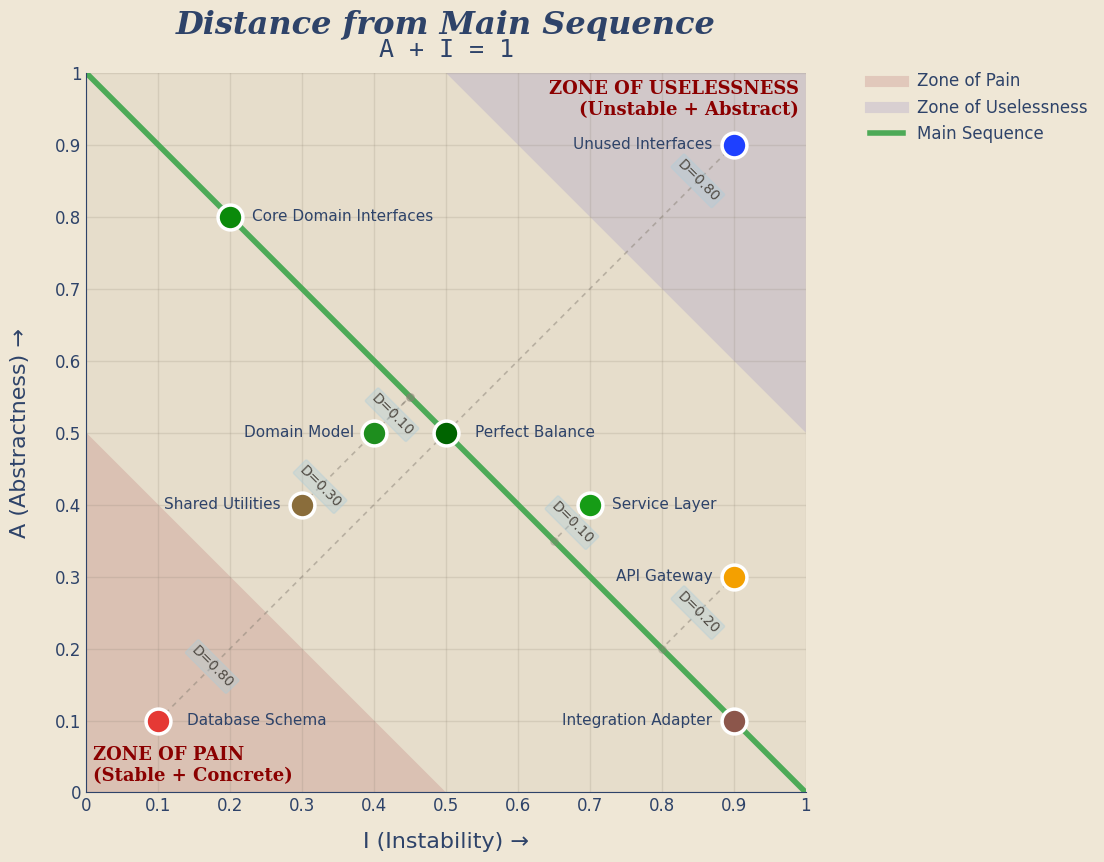

In [9]:
render_distance_from_main_sequence()

## 🗺️ Where These Metrics Apply

**These metrics apply to almost any software system:**

- microservices
- modular applications
- large monoliths (UI and/or service)
- plugin architectures
- libraries

* Microservice systems especially benefit from coupling analysis because dependencies often hide behind **network calls rather than imports**.
* A service with high efferent coupling may rely on many downstream services.
* Each dependency increases operational risk.
* Understanding coupling helps prevent systems from drifting toward the dreaded:

```text
A tightly coupled monolith
```

## 🧱 The Takeaway

Architecture is often treated as an art.

But beneath the diagrams lies something more mechanical.

Software systems obey structural forces.

Coupling is one of them.

And like gravity…

you can ignore it.

But you cannot escape it.

## 📚 References

- Martin, R. C. (1994). *OO Design Quality Metrics: An Analysis of Dependencies.*
- Martin, R. C. (2017). *Clean Architecture.*
- Lakos, J. (1996). *Large-Scale C++ Software Design.*
- Ford, N., Parsons, R., & Kua, P. (2017). *Building Evolutionary Architectures.*

In [10]:
render_md("coupling-part1.md")

✅ Markdown exported to coupling-part1.md
✅ Exported 3 output asset(s)


PosixPath('coupling-part1.md')